# Sign2Chat — Pipeline Demo 🖐️


In [2]:
import os, warnings, json
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize as MplNorm
from matplotlib import cm
from pathlib import Path
from scipy.interpolate import interp1d

import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
import random

warnings.filterwarnings('ignore')
np.random.seed(42)

# Notebook display helpers
from IPython.display import display, HTML
display(HTML("<style>div.output_area img { max-width: 100%; }</style>"))


In [3]:
PROJECT_ROOT   = Path('..').resolve()

VIDEO_PATH     = PROJECT_ROOT / 'UAE-dataset' / 'colors' / 'Colors_01_Al_Alwaan.mp4'
HOLISTIC_MODEL = PROJECT_ROOT / 'models' / 'holistic_landmarker.task'

SEQ_LEN      = 60      # target frames
N_KEYPOINTS  = 75      # 33 pose + 21 left hand + 21 right hand
N_DIMS       = 2       # (x, y)
LEFT_SHOULDER  = 11
RIGHT_SHOULDER = 12

assert VIDEO_PATH.exists(),     f"Video not found: {VIDEO_PATH}"
assert HOLISTIC_MODEL.exists(), f"Model not found: {HOLISTIC_MODEL}"

cap = cv2.VideoCapture(str(VIDEO_PATH))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps          = cap.get(cv2.CAP_PROP_FPS) or 30.0
width        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

print(f"Video   : {VIDEO_PATH.name}")
print(f"Frames  : {total_frames}  |  FPS: {fps:.1f}  |  Size: {width}×{height}")
print(f"Model   : {HOLISTIC_MODEL.name}")
print(f"Output  : ({SEQ_LEN}, {N_KEYPOINTS}, {N_DIMS})  per sample")


Video   : Colors_01_Al_Alwaan.mp4
Frames  : 250  |  FPS: 25.0  |  Size: 640×360
Model   : holistic_landmarker.task
Output  : (60, 75, 2)  per sample


## 2 — Skeleton Graph Definition
Define the anatomical edges used for both drawing and the ST-GCN graph.

In [4]:
# MediaPipe 33-joint pose connections (joint index pairs)
POSE_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,7),(0,4),(4,5),(5,6),(6,8),
    (9,10),(11,12),(11,13),(13,15),(15,17),(15,19),(15,21),(17,19),
    (12,14),(14,16),(16,18),(16,20),(16,22),(18,20),
    (11,23),(12,24),(23,24),(23,25),(24,26),(25,27),(26,28),
    (27,29),(28,30),(29,31),(30,32),(27,31),(28,32)
]

# MediaPipe 21-joint hand connections (same topology for both hands)
HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),        # thumb
    (0,5),(5,6),(6,7),(7,8),        # index
    (5,9),(9,10),(10,11),(11,12),   # middle
    (9,13),(13,14),(14,15),(15,16), # ring
    (13,17),(17,18),(18,19),(19,20),(0,17)  # pinky + palm base
]

# In the 75-joint array:  pose=0..32 | lhand=33..53 | rhand=54..74
LHAND_OFFSET = 33
RHAND_OFFSET = 54

print(f"Pose  connections : {len(POSE_CONNECTIONS)}")
print(f"Hand  connections : {len(HAND_CONNECTIONS)} (each hand)")
print(f"Total graph edges : {len(POSE_CONNECTIONS) + 2*len(HAND_CONNECTIONS)} spatial")


Pose  connections : 35
Hand  connections : 21 (each hand)
Total graph edges : 77 spatial


## 3 — Stage 1: MediaPipe Landmark Extraction

We run `HolisticLandmarker` in **VIDEO** mode, which uses temporal tracking between frames for more stable results than IMAGE mode.

The extractor returns **75 keypoints per frame**: 33 body pose + 21 left hand + 21 right hand.

In [5]:
def build_holistic_landmarker() -> mp_vision.HolisticLandmarker:
    options = mp_vision.HolisticLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=str(HOLISTIC_MODEL)),
        running_mode=mp_vision.RunningMode.VIDEO,
        min_pose_detection_confidence=0.5,
        min_pose_suppression_threshold=0.5,
        min_pose_landmarks_confidence=0.5,
        min_face_detection_confidence=0.5,
        min_face_suppression_threshold=0.5,
        min_face_landmarks_confidence=0.5,
        min_hand_landmarks_confidence=0.5,
        output_face_blendshapes=False,
    )
    return mp_vision.HolisticLandmarker.create_from_options(options)


def _lm_to_array(landmark_list, n: int) -> np.ndarray:
    """Convert a Tasks API landmark list → (n, N_DIMS) float32 array."""
    if not landmark_list:
        return np.zeros((n, N_DIMS), dtype=np.float32)
    pts = [[lm.x, lm.y] if N_DIMS == 2 else [lm.x, lm.y, lm.z]
        for lm in landmark_list]
    return np.array(pts[:n], dtype=np.float32)


def parse_result(result) -> tuple:
    """HolisticLandmarkerResult → (75, N_DIMS) array + hand_detected flag."""
    pose_lms  = result.pose_landmarks       if result.pose_landmarks       else []
    lhand_lms = result.left_hand_landmarks  if result.left_hand_landmarks  else []
    rhand_lms = result.right_hand_landmarks if result.right_hand_landmarks else []

    pose  = _lm_to_array(pose_lms,  33)
    lhand = _lm_to_array(lhand_lms, 21)
    rhand = _lm_to_array(rhand_lms, 21)

    hand_detected = bool(lhand_lms or rhand_lms)
    return np.concatenate([pose, lhand, rhand], axis=0), hand_detected, lhand_lms, rhand_lms, pose_lms


print("✅ Extractor functions defined")


✅ Extractor functions defined


In [6]:
cap = cv2.VideoCapture(str(VIDEO_PATH))
raw_frames   = []        # (T, 75, N_DIMS) raw landmarks
no_hand_mask = []        # True = no hand detected on that frame
bgr_frames   = []        # store raw BGR frames for visualization
result_list  = []        # store full results for skeleton drawing

with build_holistic_landmarker() as landmarker:
    frame_idx = 0
    while True:
        ret, bgr = cap.read()
        if not ret:
            break
        rgb      = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        mp_img   = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        ts_ms    = int(frame_idx * 1000 / fps)
        result   = landmarker.detect_for_video(mp_img, ts_ms)

        kp, hand_ok, lhand_lms, rhand_lms, pose_lms = parse_result(result)
        raw_frames.append(kp)
        no_hand_mask.append(not hand_ok)
        bgr_frames.append(bgr.copy())
        result_list.append((pose_lms, lhand_lms, rhand_lms))
        frame_idx += 1

cap.release()

raw_seq  = np.stack(raw_frames, axis=0).astype(np.float32)   # (T, 75, 2)
mask     = np.array(no_hand_mask, dtype=bool)
T        = raw_seq.shape[0]

print(f"✅ Extracted {T} frames")
print(f"    Raw sequence shape : {raw_seq.shape}")
print(f"    Frames WITH hand   : {(~mask).sum()}  ({100*(~mask).mean():.1f}%)")
print(f"    Frames no hand     : {mask.sum()}  ({100*mask.mean():.1f}%)")
print(f"    X range: [{raw_seq[:,:,0].min():.3f}, {raw_seq[:,:,0].max():.3f}]")
print(f"    Y range: [{raw_seq[:,:,1].min():.3f}, {raw_seq[:,:,1].max():.3f}]")


✅ Extracted 250 frames
    Raw sequence shape : (250, 75, 2)
    Frames WITH hand   : 70  (28.0%)
    Frames no hand     : 180  (72.0%)
    X range: [0.000, 0.732]
    Y range: [0.000, 2.255]


### 📷 Visualization A — Skeleton Overlaid on Video Frame

Draw the MediaPipe skeleton directly on a sample frame. The colored overlay shows:
- 🔵 **Blue** — body pose joints & connections  
- 🟢 **Green** — left hand joints & connections  
- 🔴 **Red** — right hand joints & connections


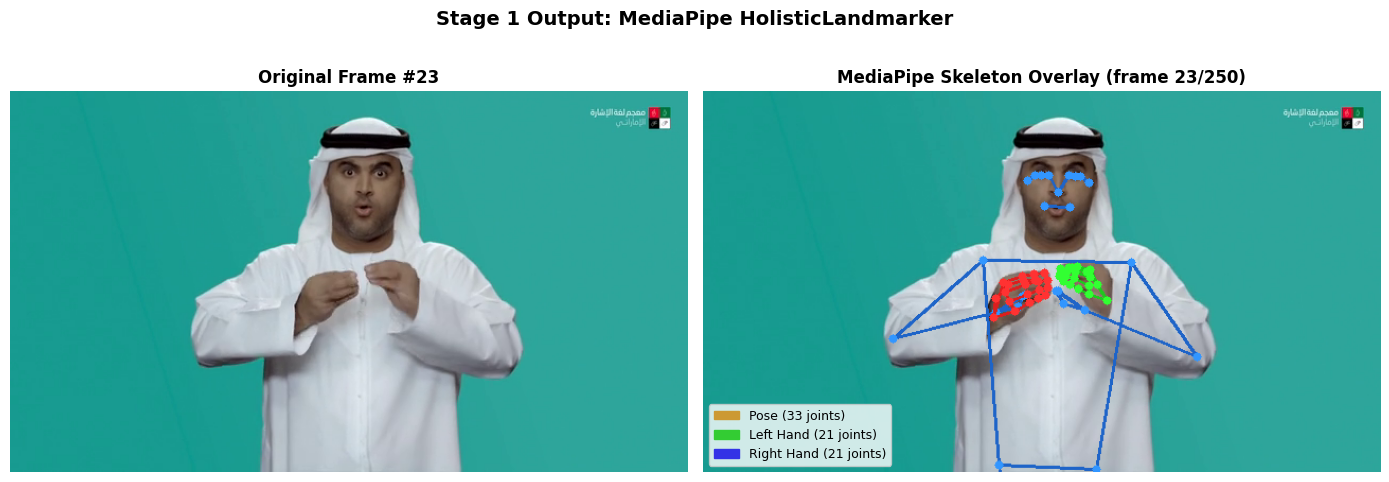

Frame shape: (360, 640, 3)  |  Landmarks: 33 pose, 21 lhand, 21 rhand


In [67]:
def draw_skeleton_on_frame(bgr_img: np.ndarray, pose_lms, lhand_lms, rhand_lms,
                            point_r=4, line_w=2) -> np.ndarray:
    """Draw MediaPipe landmarks and connections onto a BGR frame."""
    img = bgr_img.copy()
    h, w = img.shape[:2]

    def px(lm):
        return int(lm.x * w), int(lm.y * h)

    # Pose (blue)
    if pose_lms:
        for a, b in POSE_CONNECTIONS:
            if a < len(pose_lms) and b < len(pose_lms):
                cv2.line(img, px(pose_lms[a]), px(pose_lms[b]), (200, 100, 30), line_w)
        for lm in pose_lms:
            cv2.circle(img, px(lm), point_r, (255, 150, 50), -1)

    # Left hand (green)
    if lhand_lms:
        for a, b in HAND_CONNECTIONS:
            if a < len(lhand_lms) and b < len(lhand_lms):
                cv2.line(img, px(lhand_lms[a]), px(lhand_lms[b]), (30, 200, 30), line_w)
        for lm in lhand_lms:
            cv2.circle(img, px(lm), point_r, (50, 255, 50), -1)

    # Right hand (red)
    if rhand_lms:
        for a, b in HAND_CONNECTIONS:
            if a < len(rhand_lms) and b < len(rhand_lms):
                cv2.line(img, px(rhand_lms[a]), px(rhand_lms[b]), (30, 30, 220), line_w)
        for lm in rhand_lms:
            cv2.circle(img, px(lm), point_r, (50, 50, 255), -1)

    return img


# Pick a frame near the middle of the video (usually most informative)
sample_idx = random.randint(0, T-100)
pose_lms, lhand_lms, rhand_lms = result_list[sample_idx]
annotated  = draw_skeleton_on_frame(bgr_frames[sample_idx], pose_lms, lhand_lms, rhand_lms)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(bgr_frames[sample_idx], cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Original Frame #{sample_idx}", fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"MediaPipe Skeleton Overlay (frame {sample_idx}/{T})", fontsize=12, fontweight='bold')
axes[1].axis('off')

# Legend
legend = [
    mpatches.Patch(color=(0.8, 0.6, 0.2), label='Pose (33 joints)'),
    mpatches.Patch(color=(0.2, 0.8, 0.2), label='Left Hand (21 joints)'),
    mpatches.Patch(color=(0.2, 0.2, 0.9), label='Right Hand (21 joints)'),
]
axes[1].legend(handles=legend, loc='lower left', fontsize=9, framealpha=0.8)
plt.suptitle("Stage 1 Output: MediaPipe HolisticLandmarker", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(f"Frame shape: {bgr_frames[sample_idx].shape}  |  Landmarks: {len(pose_lms)} pose, {len(lhand_lms)} lhand, {len(rhand_lms)} rhand")


### 📽️ Visualization B — Skeleton Strip Across Time
Sample 8 evenly-spaced frames to show how the pose evolves through the sign.

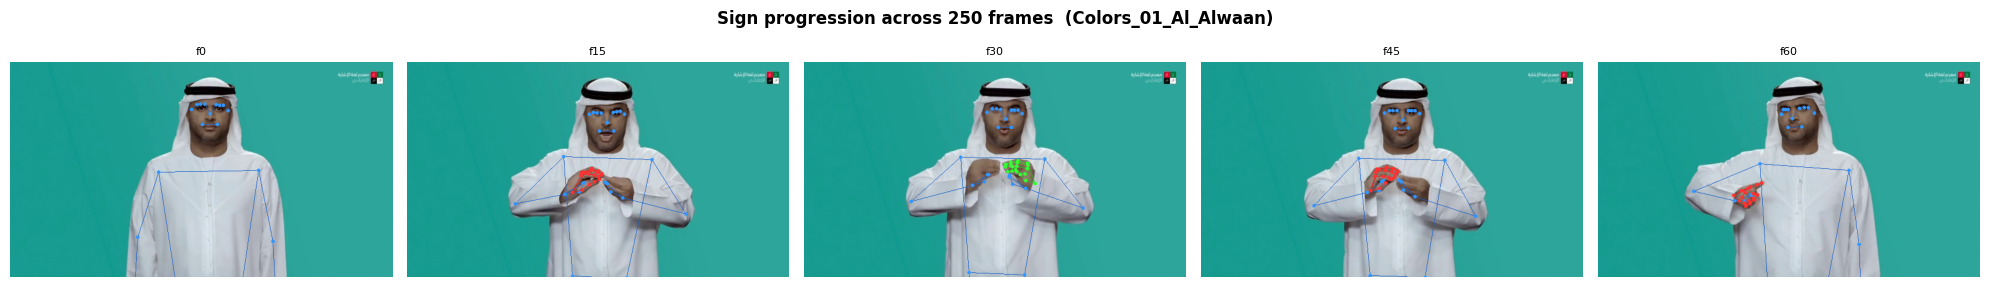

In [8]:
n_strip = 5
strip_indices = np.linspace(0, T - 190, n_strip, dtype=int)

fig, axes = plt.subplots(1, n_strip, figsize=(20, 3))
for ax, idx in zip(axes, strip_indices):
    pose_l, lhand_l, rhand_l = result_list[idx]
    ann = draw_skeleton_on_frame(bgr_frames[idx], pose_l, lhand_l, rhand_l, point_r=3, line_w=1)
    ax.imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
    ax.set_title(f"f{idx}", fontsize=8)
    ax.axis('off')

plt.suptitle(f"Sign progression across {T} frames  ({VIDEO_PATH.stem})", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
